<a href="https://colab.research.google.com/github/ithelga/beeline-banner-ab-test/blob/dev/notebooks/Team1_HW4_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SmartAds Efficiency**: Оптимизация эффективности маркетинговых каналов

## [STAGE 3] **Проведение разведывательного анализа (EDA)**

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
import polars as pl
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

colors = ["#282828", "#F5C341", "#FFDB7D", "#F0F0F0", "#FFFFFF"] # Основная палитра

graph_path = 'drive/MyDrive/Colab Notebooks/Beeline Banner AB-test/graph'
data_path = 'drive/MyDrive/Colab Notebooks/Beeline Banner AB-test/data'

Mounted at /content/drive


In [30]:
# Настройка визуалзаций
plt.rcParams['figure.facecolor'] = colors[3]   # фон вокруг области построения
plt.rcParams['axes.facecolor'] = colors[4]     # фон внутри графика
plt.rcParams['axes.edgecolor'] = colors[0]     # рамка графика

plt.rcParams['text.color'] = colors[0]         # общий цвет текста
plt.rcParams['axes.labelcolor'] = colors[0]    # подписи осей
plt.rcParams['xtick.color'] = colors[0]        # подписи по оси X
plt.rcParams['ytick.color'] = colors[0]        # подписи по оси Y

### Загружаем данные с Google Disk

In [31]:
supertable = pd.read_csv(f'{data_path}/supertable.csv')
supertable.head()

,user_id,timestamp,date,shows,clicks,banner_first,campaign_first,placement,device_type,os,geo,has_install_event,has_first_order_event,has_registration_event,has_tariff_switch_event,segment,tariff,creative_type,size,target_audience_segment
0,1,2025-02-10 10:06:23,NaN,0,0,NaN,no_impression,NaN,NaN,NaN,NaN,0,0,0,0,premium,premium,no_impression,no_impression,no_impression
1,1,2025-02-15 20:05:59,NaN,0,0,NaN,no_impression,NaN,NaN,NaN,NaN,0,0,0,0,premium,premium,no_impression,no_impression,no_impression
2,1,2025-02-16 08:34:35,NaN,0,0,NaN,no_impression,NaN,NaN,NaN,NaN,0,0,0,0,premium,premium,no_impression,no_impression,no_impression
3,1,2025-02-17 21:55:14,NaN,0,0,NaN,no_impression,NaN,NaN,NaN,NaN,0,0,0,0,premium,premium,no_impression,no_impression,no_impression
4,1,2025-03-01 20:13:19,NaN,0,0,NaN,no_impression,NaN,NaN,NaN,NaN,0,0,0,0,premium,premium,no_impression,no_impression,no_impression


### Общая информация о витрине

Проверяем размерность, типы данных, диапазон дат и базовые характеристики.

In [32]:
print("Размер витрины (строки, столбцы):", supertable.shape)

# Диапазон дат по временным полям
for col in ["timestamp", "date"]:
    if col in supertable.columns:
        print(f"\nПоле '{col}':")
        s = supertable[col]
        # Если уже datetime — просто берём min/max
        if np.issubdtype(s.dtype, np.datetime64):
            print("  минимальная дата:", s.min())
            print("  максимальная дата:", s.max())
        else:
            # Пробуем привести к datetime, игнорируя некорректные значения
            s_dt = pd.to_datetime(s, errors="coerce")
            if s_dt.notna().any():
                print("  минимальная дата:", s_dt.min())
                print("  максимальная дата:", s_dt.max())
            else:
                # Если привести к дате не удалось, просто покажем примеры значений
                print("  не удалось корректно интерпретировать как дату, пример значений:")
                print(s.head())

# Количество уникальных пользователей
if "user_id" in supertable.columns:
    print("\nУникальных пользователей:", supertable["user_id"].nunique())

# Типы данных
supertable.dtypes

Размер витрины (строки, столбцы): (1171848, 20)

Поле 'timestamp':
  минимальная дата: 2025-02-01 00:00:04
  максимальная дата: 2025-03-17 23:59:53

Поле 'date':
  минимальная дата: 2025-02-01 00:00:00
  максимальная дата: 2025-04-08 00:00:00

Уникальных пользователей: 100000


,0
user_id,int64
timestamp,object
date,object
shows,int64
clicks,int64
banner_first,float64
campaign_first,object
placement,object
device_type,object
os,object


### Пропуски и базовые распределения

Смотрим долю пропусков по столбцам и базовые распределения по основным признакам.

In [33]:
# Доля пропусков по каждому столбцу
missing_share = supertable.isna().mean().sort_values(ascending=False)
missing_share

,0
device_type,0.998651
os,0.998651
placement,0.998651
banner_first,0.998651
geo,0.998651
date,0.993806
timestamp,0.006194
user_id,0.000000
shows,0.000000
clicks,0.000000


In [34]:
# Пример распределений по ключевым полям
for col in ["shows", "clicks"]:
    if col in supertable.columns:
        print(f"\nОписательная статистика по '{col}':")
        print(supertable[col].describe())


Описательная статистика по 'shows':
count    1.171848e+06
mean     1.548836e-03
std      4.451571e-02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.000000e+00
Name: shows, dtype: float64

Описательная статистика по 'clicks':
count    1.171848e+06
mean     1.339764e-04
std      1.157405e-02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: clicks, dtype: float64


### Общая воронка маркетинга

Строим агрегированную воронку: показы → клики → установившие приложение → зарегистрировавшиеся → первый заказ → смена тарифа.

In [35]:
# Функция для подсчёта числа пользователей на каждом шаге воронки
def funnel_counts(df):
    res = {}
    # Пользователи с хотя бы одним показом
    if {"shows", "user_id"}.issubset(df.columns):
        res["shows_users"] = df.loc[df["shows"] > 0, "user_id"].nunique()
    # Пользователи с хотя бы одним кликом
    if {"clicks", "user_id"}.issubset(df.columns):
        res["clicks_users"] = df.loc[df["clicks"] > 0, "user_id"].nunique()
    # Флаги событий
    flags = [
        ("has_install_event", "install_users"),
        ("has_registration_event", "registration_users"),
        ("has_first_order_event", "first_order_users"),
        ("has_tariff_switch_event", "tariff_switch_users"),
    ]
    for flag_col, name in flags:
        if flag_col in df.columns:
            res[name] = df.loc[df[flag_col] == 1, "user_id"].nunique()
    return res

funnel = funnel_counts(supertable)
funnel_df = pd.DataFrame(
    {
        "stage": [
            "Показ (есть ≥1 показ)",
            "Клик (есть ≥1 клик)",
            "Установка приложения",
            "Регистрация",
            "Первый заказ",
            "Смена тарифа",
        ],
        "users": [
            funnel.get("shows_users", np.nan),
            funnel.get("clicks_users", np.nan),
            funnel.get("install_users", np.nan),
            funnel.get("registration_users", np.nan),
            funnel.get("first_order_users", np.nan),
            funnel.get("tariff_switch_users", np.nan),
        ],
    }
)

funnel_df

,stage,users
0,Показ (есть ≥1 показ),1303
1,Клик (есть ≥1 клик),156
2,Установка приложения,3120
3,Регистрация,2920
4,Первый заказ,2416
5,Смена тарифа,1217


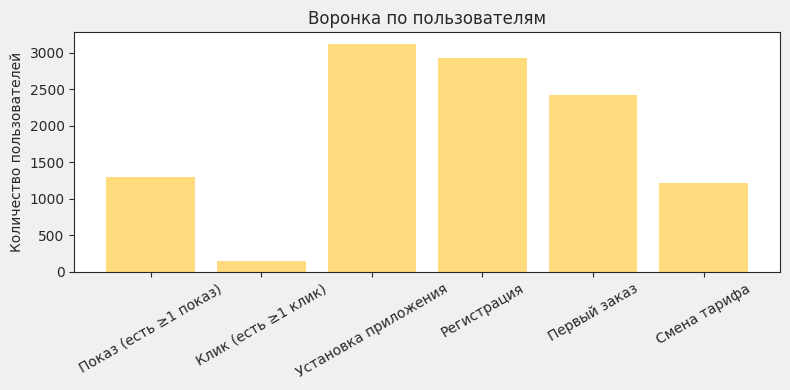

In [36]:
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor(colors[3])
ax.set_facecolor(colors[4])

ax.bar(funnel_df["stage"], funnel_df["users"], color=colors[2])
ax.set_title("Воронка по пользователям")
ax.set_ylabel("Количество пользователей")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(f'{graph_path}/user_funnel.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

### Динамика метрик во времени

Смотрим, как меняются ключевые метрики по дням: показы, клики, CTR, конверсии.

,date,shows,clicks,reg_users,first_order_users,tariff_switch_users,ctr
0,2025-02-01,16,2,31,3,0,0.125000
1,2025-02-02,21,1,52,18,0,0.047619
2,2025-02-03,24,0,70,37,0,0.000000
3,2025-02-04,30,4,79,46,1,0.133333
4,2025-02-05,29,4,73,54,5,0.137931


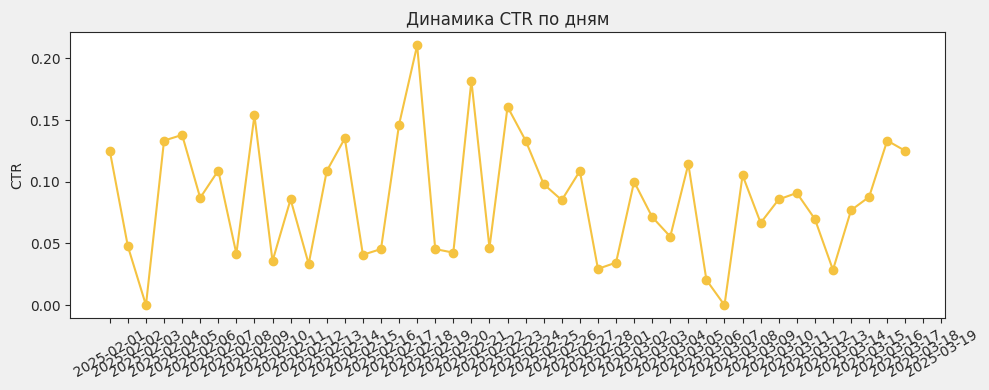

In [38]:
if "date" in supertable.columns:
    analytics_daily = (
        supertable
        .groupby("date")
        .agg(
            shows=("shows", "sum"),
            clicks=("clicks", "sum"),
            reg_users=("has_registration_event", "sum"),
            first_order_users=("has_first_order_event", "sum"),
            tariff_switch_users=("has_tariff_switch_event", "sum"),
        )
        .reset_index()
    )
    analytics_daily["ctr"] = analytics_daily["clicks"] / analytics_daily["shows"]

    display(analytics_daily.head())

    fig, ax = plt.subplots(figsize=(10, 4))
    fig.patch.set_facecolor(colors[3])
    ax.set_facecolor(colors[4])

    ax.plot(analytics_daily["date"], analytics_daily["ctr"], marker="o", color=colors[1])
    ax.set_title("Динамика CTR по дням")
    ax.set_ylabel("CTR")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.savefig(f'{graph_path}/ctr_time_series.png', format='png', dpi=600, bbox_inches='tight')
    plt.show()

else:
    print("Колонка 'date' отсутствует, пропускаем анализ динамики.")

### Сегментный анализ (OS, устройство, placement, креатив, география)

Строим сводную таблицу метрик по ключевым срезам и визуализируем CTR и конверсии.

In [39]:
def segment_stats(df, group_col):
    # Базовые агрегации
    grouped = df.groupby(group_col)

    base = grouped.agg(
        users=("user_id", "nunique"),
        shows=("shows", "sum"),
        clicks=("clicks", "sum"),
    ).reset_index()

    def unique_with_flag(g, flag_col):
        if flag_col not in g.columns:
            return np.nan
        return g.loc[g[flag_col] == 1, "user_id"].nunique()

    extras = grouped.apply(
        lambda g: pd.Series(
            {
                "has_install": unique_with_flag(g, "has_install_event"),
                "has_registration": unique_with_flag(g, "has_registration_event"),
                "has_first_order": unique_with_flag(g, "has_first_order_event"),
                "has_tariff_switch": unique_with_flag(g, "has_tariff_switch_event"),
            }
        )
    ).reset_index()

    stats = base.merge(extras, on=group_col)

    # Производные метрики
    stats["ctr"] = stats["clicks"] / stats["shows"]
    stats["cr_inst_reg"] = stats["has_registration"] / stats["has_install"]
    stats["cr_reg_ord"] = stats["has_first_order"] / stats["has_registration"]
    stats["cr_reg_sw"] = stats["has_tariff_switch"] / stats["has_registration"]
    stats["cr_all"] = stats["has_tariff_switch"] / stats["shows"]

    return stats

#### Формальные определения метрик и проверка гипотез (описательный уровень)

**Определения метрик**

Для каждой группы (g) (например, OS, тип креатива, placement, тип устройства) определим:

- **Показы**: ($\text{shows}_g$)
- **Клики**: ($\text{clicks}_g$)
- **Число пользователей с регистрацией**: ($\text{reg_users}_g$)
- **Число пользователей со сменой тарифа**: ($\text{tariff_switch_users}_g$)

Тогда:

- **CTR группы (g)**

  $$ CTR_g = \frac{\text{clicks}_g}{\text{shows}_g}. $$

- **Вероятность смены тарифа после регистрации** (конверсия регистрация → смена тарифа):

  $$ p^{\text{reg} \rightarrow \text{sw}}_g =
  \frac{\text{tariff_switch_users}_g}{\text{reg_users}_g}. $$

- **Финальная конверсия показ → смена тарифа**:

  $$ p^{\text{show} \rightarrow \text{sw}}_g =
  \frac{\text{tariff_switch_users}_g}{\text{shows}_g}. $$


---


OS метрики


,os,users,shows,clicks,has_install,has_registration,has_first_order,has_tariff_switch,ctr,cr_inst_reg,cr_reg_ord,cr_reg_sw,cr_all
0,android,639,763,67,387,359,243,105,0.087811,0.927649,0.676880,0.292479,0.137615
1,ios,670,920,75,397,366,277,97,0.081522,0.921914,0.756831,0.265027,0.105435
2,web,130,132,15,77,73,40,17,0.113636,0.948052,0.547945,0.232877,0.128788


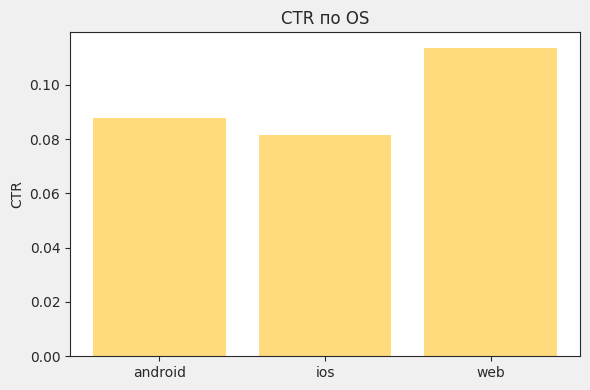

In [40]:
# OS
if "os" in supertable.columns:
    os_stats = segment_stats(supertable, "os")
    print("OS метрики")
    display(os_stats)

    fig, ax = plt.subplots(figsize=(6, 4))
    fig.patch.set_facecolor(colors[3])
    ax.set_facecolor(colors[4])

    ax.bar(os_stats["os"], os_stats["ctr"], color=colors[2])
    ax.set_title("CTR по OS")
    ax.set_ylabel("CTR")
    plt.tight_layout()
    plt.savefig(f'{graph_path}/segments_os.png', format='png', dpi=600, bbox_inches='tight')
    plt.show()

#### Гипотеза 2  
> Пользователи веб-версии не менее, чем на 30% чаще кликают на рекламу (CTR), чем пользователи мобильного приложения.

Обозначим:

- ($ CTR_{\text{web}} $) — CTR web-пользователей,
- ($ CTR_{\text{mob}} $) — средний CTR по Android и iOS:

  $$
  CTR_{\text{mob}} = \frac{CTR_{\text{android}} + CTR_{\text{iOS}}}{2}.
  $$

Гипотеза:

$$ H_{2}: \quad CTR_{\text{web}} \ge 1.30 \cdot CTR_{\text{mob}}. $$

По данным EDA:

- $$ \widehat{CTR}_{\text{android}} \approx 0.0878, \quad
\widehat{CTR}_{\text{iOS}} \approx 0.0815, $$
- $$ \widehat{CTR}_{\text{mob}} \approx 0.0847, \quad
\widehat{CTR}_{\text{web}} \approx 0.1136. $$

Относительный прирост:

$$
\widehat{\text{lift}}_{2}
= \frac{\widehat{CTR}_{\text{web}}}{\widehat{CTR}_{\text{mob}}} - 1
\approx 0.34 \ (\text{+34%}),
$$

что **превышает требуемые 30%**. На описательном уровне гипотеза поддерживается.


---

placement метрики


,placement,users,shows,clicks,has_install,has_registration,has_first_order,has_tariff_switch,ctr,cr_inst_reg,cr_reg_ord,cr_reg_sw,cr_all
0,app,562,679,66,331,318,205,96,0.097202,0.960725,0.644654,0.301887,0.141384
1,site,591,744,57,352,315,237,81,0.076613,0.894886,0.752381,0.257143,0.108871
2,social,321,392,34,180,166,120,44,0.086735,0.922222,0.722892,0.265060,0.112245


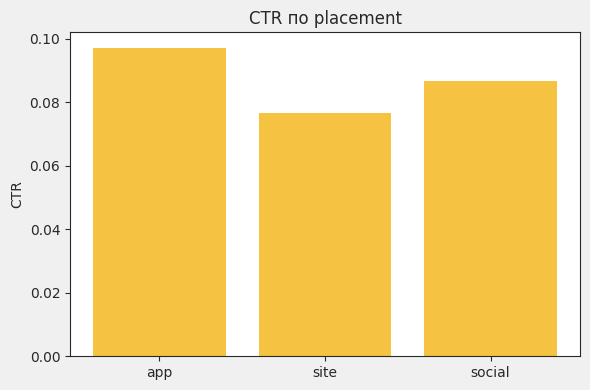

In [41]:
# Placement
if "placement" in supertable.columns:
    placement_stats = segment_stats(supertable, "placement")
    print("placement метрики")
    display(placement_stats)

    fig, ax = plt.subplots(figsize=(6, 4))
    fig.patch.set_facecolor(colors[3])
    ax.set_facecolor(colors[4])

    ax.bar(placement_stats["placement"], placement_stats["ctr"], color=colors[1])
    ax.set_title("CTR по placement")
    ax.set_ylabel("CTR")
    plt.tight_layout()
    plt.savefig(f'{graph_path}/segments_placement.png', format='png', dpi=600, bbox_inches='tight')
    plt.show()

#### Гипотеза 3  
> Размещение рекламы в приложении увеличивает вероятность смены тарифа не менее чем на 25% по сравнению с сайтом/соц сетями.

Обозначим:

- ($ p^{\text{show} \rightarrow \text{sw}}_{\text{app}} $) — конверсия показ → смена тарифа в приложении,
- ($ p^{\text{show} \rightarrow \text{sw}}_{\text{site}} $) — аналогично для сайта,
- ($ p^{\text{show} \rightarrow \text{sw}}_{\text{social}} $) — для соцсетей.

Гипотеза:

$$ H_{3}: \quad
p^{\text{show} \rightarrow \text{sw}}_{\text{app}}
\ge 1.25 \cdot p^{\text{show} \rightarrow \text{sw}}_{\text{site}},
\quad \text{и}
\quad
p^{\text{show} \rightarrow \text{sw}}_{\text{app}}
\ge 1.25 \cdot p^{\text{show} \rightarrow \text{sw}}_{\text{social}}.
$$

По данным EDA:

- $$ \widehat{p}^{\text{show} \rightarrow \text{sw}}_{\text{site}} \approx 0.109, \quad
\widehat{p}^{\text{show} \rightarrow \text{sw}}_{\text{app}} \approx 0.141, \quad
\widehat{p}^{\text{show} \rightarrow \text{sw}}_{\text{social}} \approx 0.112. $$

Lifts:

$$
\widehat{\text{lift}}^{\text{app vs site}}_{3}
= \frac{\widehat{p}_{\text{app}}}{\widehat{p}_{\text{site}}} - 1
\approx 0.30 \ (\text{+30%}),
$$

$$
\widehat{\text{lift}}^{\text{app vs social}}_{3}
= \frac{\widehat{p}_{\text{app}}}{\widehat{p}_{\text{social}}} - 1
\approx 0.26 \ (\text{+26%}),
$$

что **больше порога 25%**. На описательном уровне гипотеза подтверждается.


---

device_type метрики


,device_type,users,shows,clicks,has_install,has_registration,has_first_order,has_tariff_switch,ctr,cr_inst_reg,cr_reg_ord,cr_reg_sw,cr_all
0,phone,1142,1529,137,726,671,470,182,0.089601,0.924242,0.700447,0.271237,0.119032
1,tablet,243,286,20,131,123,89,37,0.069930,0.938931,0.723577,0.300813,0.129371


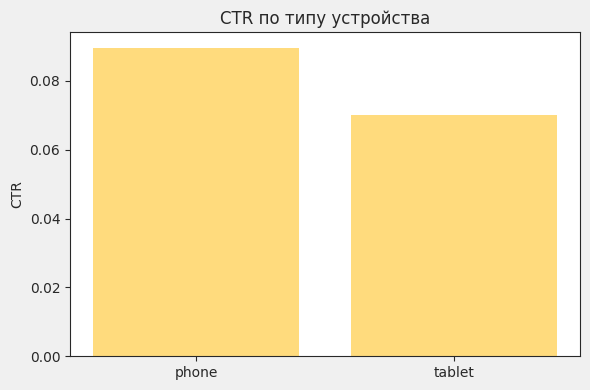

In [42]:
# Тип устройства
if "device_type" in supertable.columns:
    device_stats = segment_stats(supertable, "device_type")
    print("device_type метрики")
    display(device_stats)

    fig, ax = plt.subplots(figsize=(6, 4))
    fig.patch.set_facecolor(colors[3])
    ax.set_facecolor(colors[4])

    ax.bar(device_stats["device_type"], device_stats["ctr"], color=colors[2])
    ax.set_title("CTR по типу устройства")
    ax.set_ylabel("CTR")
    plt.tight_layout()
    plt.savefig(f'{graph_path}/segments_device_type.png', format='png', dpi=600, bbox_inches='tight')
    plt.show()

#### Гипотеза 4  
> Просмотр рекламы на устройстве tablet увеличивает вероятность смены тарифа более, чем на 10 %  по сравнению с другими устройствами после регистрации пользователей.

Обозначим:

- ($ p^{\text{reg} \rightarrow \text{sw}}_{\text{phone}} $) — конверсия регистрация → смена тарифа для phone,
- ($ p^{\text{reg} \rightarrow \text{sw}}_{\text{tablet}} $) — то же для tablet.

Гипотеза:

$$ H_{4}: \quad
p^{\text{reg} \rightarrow \text{sw}}_{\text{tablet}}
> 1.10 \cdot p^{\text{reg} \rightarrow \text{sw}}_{\text{phone}}.
$$

По данным EDA:

- $$ \widehat{p}^{\text{reg} \rightarrow \text{sw}}_{\text{phone}} \approx 0.271, \quad
\widehat{p}^{\text{reg} \rightarrow \text{sw}}_{\text{tablet}} \approx 0.301. $$

Относительный прирост:

$$
\widehat{\text{lift}}_{4}
= \frac{\widehat{p}_{\text{tablet}}}{\widehat{p}_{\text{phone}}} - 1
\approx 0.11 \ (\text{+11%}),
$$

что **чуть выше порога 10%**. На описательном уровне гипотеза подтверждается.


creative_type метрики


,creative_type,users,shows,clicks,has_install,has_registration,has_first_order,has_tariff_switch,ctr,cr_inst_reg,cr_reg_ord,cr_reg_sw,cr_all
0,no_impression,100000,0,0,2433,2277,1966,1020,NaN,0.935882,0.863417,0.447958,inf
1,rich,104,124,10,66,58,35,13,0.080645,0.878788,0.603448,0.224138,0.104839
2,static,767,974,76,463,426,300,118,0.078029,0.920086,0.704225,0.276995,0.121150
3,video,566,717,71,331,313,223,89,0.099024,0.945619,0.712460,0.284345,0.124128


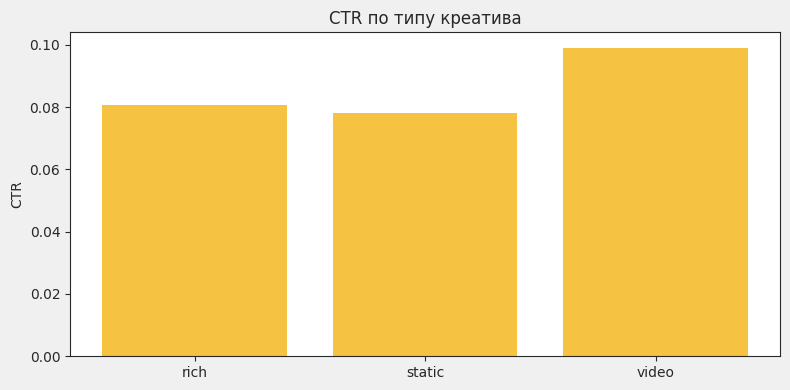

In [43]:
# Тип креатива
if "creative_type" in supertable.columns:
    creative_stats = segment_stats(supertable, "creative_type")
    print("creative_type метрики")
    display(creative_stats)

    fig, ax = plt.subplots(figsize=(8, 4))
    fig.patch.set_facecolor(colors[3])
    ax.set_facecolor(colors[4])

    ax.bar(creative_stats["creative_type"], creative_stats["ctr"], color=colors[1])
    ax.set_title("CTR по типу креатива")
    ax.set_ylabel("CTR")
    plt.tight_layout()
    plt.savefig(f'{graph_path}/segments_creative_type.png', format='png', dpi=600, bbox_inches='tight')
    plt.show()

#### Гипотеза 1  
> Показ анимированного баннера дает CTR более чем на 25% выше по сравнению со статичным баннером.

Обозначим:

- ($ CTR_{\text{static}} $) — CTR статичных баннеров,
- ($ CTR_{\text{anim}} $) — CTR анимированных/видео баннеров.

Формулировка гипотезы в терминах CTR:

$$ H_{1}: \quad CTR_{\text{anim}} > 1.25 \cdot CTR_{\text{static}}. $$

По данным EDA:

- $$ \widehat{CTR}_{\text{static}} \approx 0.078, \quad
\widehat{CTR}_{\text{anim}} \approx 0.099. $$

Относительный прирост (lift):

$$
\widehat{\text{lift}}_{1}
= \frac{\widehat{CTR}_{\text{anim}}}{\widehat{CTR}_{\text{static}}} - 1
\approx 0.27 \ (\text{+27%}),
$$

что **больше заявленных 25%**. На описательном уровне гипотеза подтверждается.


---


geo метрики (топ-5 по показам)


,geo,users,shows,clicks,has_install,has_registration,has_first_order,has_tariff_switch,ctr,cr_inst_reg,cr_reg_ord,cr_reg_sw,cr_all
2,Москва,436,522,52,259,240,156,68,0.099617,0.926641,0.650000,0.283333,0.130268
8,Санкт-Петербург,195,223,15,103,99,75,27,0.067265,0.961165,0.757576,0.272727,0.121076
5,Омск,145,181,17,82,77,59,17,0.093923,0.939024,0.766234,0.220779,0.093923
6,Ростов-на-Дону,153,167,16,82,77,60,21,0.095808,0.939024,0.779221,0.272727,0.125749
4,Новосибирск,145,164,12,77,76,47,23,0.073171,0.987013,0.618421,0.302632,0.140244


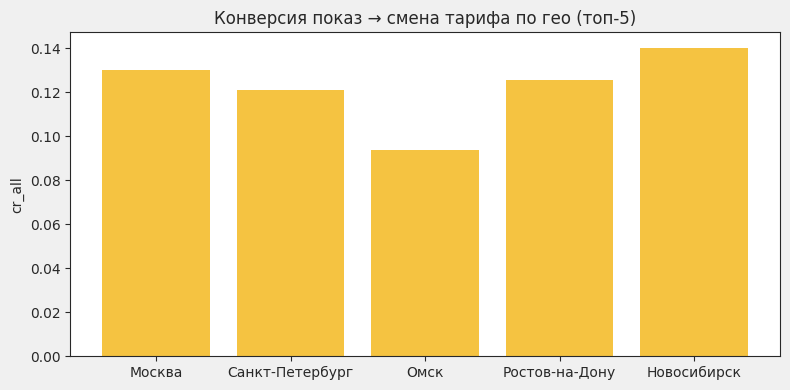

In [28]:
# География (топ-5 по показам)
if "geo" in supertable.columns:
    geo_stats = segment_stats(supertable, "geo").sort_values("shows", ascending=False)
    print("geo метрики (топ-5 по показам)")
    display(geo_stats.head())

    top5 = geo_stats.head(5)
    fig, ax = plt.subplots(figsize=(8, 4))
    fig.patch.set_facecolor(colors[3])
    ax.set_facecolor(colors[4])

    ax.bar(top5["geo"], top5["cr_all"], color=colors[1])
    ax.set_title("Конверсия показ → смена тарифа по гео (топ-5)")
    ax.set_ylabel("cr_all")
    plt.tight_layout()
    plt.savefig(f'{graph_path}/segments_geo.png', format='png', dpi=600, bbox_inches='tight')
    plt.show()

### Резюме инсайтов: итоги EDA и статус гипотез

**Общая эффективность и данные.**  
Итоговая витрина supertable содержит ~1,17 млн строк и 20 полей. Общий CTR кампании по всем placement составляет ~8,65% (157 кликов на 1 815 показов).

Верхняя часть воронки (показ → клик) отражает эффективность баннеров (около 12% пользователей с показами совершают клик).

Для нижней части воронки (установка → регистрация → первый заказ → смена тарифа) наблюдается наложение эффектов баннеров и других источников (органика, прошлые кампании), поэтому её стоит трактовать как общий путь пользователя, а не чистую последовательную воронку именно после баннеров. Данная часть сужается ожидаемо, основные потери приходятся на шаги после регистрации.

Критичных проблем с качеством данных после предварительной обработки не обнаружено, однако для метрик по установке приложения выявлено ограничение (см. ниже).

**Гипотеза 1.**  
> Показ анимированного/видеобаннера даёт CTR более чем на 25% выше по сравнению со статичным баннером.

По данным EDA: CTR  статичсного баннера ≈0,078, CTR анимированного — ≈0,099; относительный прирост ≈+27%. Гипотеза поддерживается на уровне описательной статистики и может быть вынесена в A/B-тест.

**Гипотеза 2.**  
> Пользователи веб-версии не менее чем на 30% чаще кликают на рекламу (CTR), чем пользователи мобильного приложения.  

По данным EDA: средний CTR мобильных платформ (android+iOS) ≈0,085, CTR web ≈0,114; прирост ≈+34%. Гипотеза описательно подтверждается, но в дальнейшем при тестировании важно учитывать различия в составе аудитории (гео, сегменты).

**Гипотеза 3.**  
> Размещение рекламы в приложении увеличивает вероятность смены тарифа не менее чем на 25% по сравнению с сайтом/соцсетями.  

По данным EDA: конверсия показ → смена тарифа в приложении ≈0,141, на сайте ≈0,109, в соцсетях ≈0,112; прирост для app составляет ≈+26%. Гипотеза поддерживается и выглядит приоритетной для последующей апробации.

**Гипотеза 4.**  
> Просмотр рекламы на устройстве tablet увеличивает вероятность смены тарифа более чем на 10% по сравнению с другими устройствами после регистрации пользователей.  

По данным EDA: конверсия регистрация → смена тарифа для phone ≈0,271, для tablet ≈0,301; прирост ≈+11%. Гипотеза также поддерживается на уровне описательной статистики.

**Ограничения по установкам.**  
При попытке анализировать конверсию в установку выяснилось, что число пользователей с установками (по таблице Installs) может превышать число пользователей с показами баннеров, так как в Installs смешаны установки от баннеров, органики и других источников, а также есть показы внутри уже установленного приложения (placement = app). Поэтому конверсию клика в установку мы не используем как ключевую метрику в текущих гипотезах и фиксируем это как ограничение качества данных.

**Вывод.**  
Все четыре финальные гипотезы подтверждаются на уровне EDA и будут вынесены на следующий этап (апробация/CDA), где планируется формальная проверка эффектов (A/B-тесты, критерии для долей) с учётом возможных смешивающих факторов (география, сегменты аудитории, тип устройства).
